In [1]:
from math import isinf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import persim
from skfda.representation.grid import FDataGrid
from skfda.preprocessing.dim_reduction.feature_extraction import FPCA
from lifelines import CoxPHFitter
import collections
from Project1.A1.gudhi_persistence import persim_diagram


C:\Users\sranasin\AppData\Local\Temp\ipykernel_8128\1296274595.py:8: DeprecationWarning: The module "feature_extraction" is deprecated.Please use "dim_reduction" for FPCAor "feature_construction" for feature construction techniques
  from skfda.preprocessing.dim_reduction.feature_extraction import FPCA


In [ ]:
#### Contaigion Map for i-nodes, j-realizations

J = 2 # ALl combination of seeding sites
N = 10 # number of ndoes
T = 3 # Max Time/Filatration Steps
dim = 2

betti_curves = [{0: {0: 2, 1: 0, 2: 0}, 1: {0: 1, 1: 4, 2: 0}, 2: {0: 1, 1: 10, 2: 0}},
                {0: {0: 2, 1: 0, 2: 0}, 1: {0: 1, 1: 4, 2: 0}, 2: {0: 1, 1: 10, 2: 0}}]
activation_times = [np.array([1., 0., 0., 1., 1., 2., 2., 2., 1., 1.]).astype(int),
                    np.array([1., 0., 0., 1., 1., 2., 2., 2., 1., 1.]).astype(int)]


In [ ]:
#######------- Create grid for landscaspe
rows = []
for j in range(J):
    grid = np.arange(T)
    betti_fdata = FDataGrid(data_matrix=betti_curves[j], grid_points=grid)

    ### --- We need functional PC's
    fpca = FPCA(n_components=3)
    scores = fpca.fit_transform(betti_fdata)[None, :]

    for i in range(N):
        rows.append({
            'T': activation_times[j, i],
            'E': 1,
            'cluster': j,
            **{f'FPCA{k+1}': scores[0, k] for k in range(scores.shape[1])}
        })

df = pd.DataFrame(rows)


In [4]:
import importlib, os
import numpy as np, networkx as nx, gudhi as gd
from IPython.display import display

import gudhi_persistence as gp
import utilsA1 as utils
import test_WTM as wtm
from persim import PersLandscapeApprox

<module 'gudhi_persistence' from 'U:\\Academic\\NetworkModels\\Project1\\A1\\gudhi_persistence.py'>

In [13]:

importlib.reload(wtm)
importlib.reload(utils)
importlib.reload(gp)
params_temp_list = {'num_nodes': 60, 'num_neighbor_nodes': 1,
                    'total_random_edges': 3, 'distance_threshold': 2, 'weighted': False,
                    'ngeo_placement': 'ngeo_per_node', 'n_seeds': 2, 'node_active_threshold': 0.01,
                    'upper_weight_limit': 5, 'skew_power': 3, 'seed_cluster_distance': 10,
                    'ngeom_edges_in_persistence': False, 'max_persistence_dim': 2,
                    'seeding_method': 'cluster_seeding'}

params_temp_list['threshold_sum']= sum(range(params_temp_list['num_nodes'])) - 1

G, seed_nodes = wtm.simulate_contagion_map(params=params_temp_list)
graph, snapshots, activation_times, results = wtm.simulate_contagion_realization(graph = G, init_seeds = seed_nodes, params = params_temp_list,
max_steps = 100, sim_id = 1, realization_id = 1)

ValueError: too many values to unpack (expected 2)

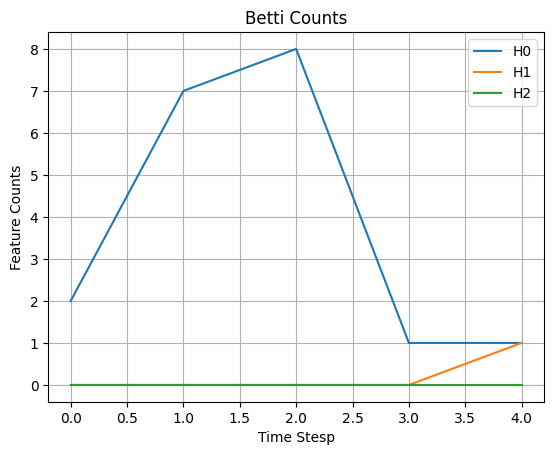

In [207]:

betti_numbers, simplex_intervals, direct_persistence_intervals = gp.compute_persistence(graph=graph, activation_times=activation_times, max_dim=2)
gp.betti_nums_over_time(betti_over_time=betti_numbers)

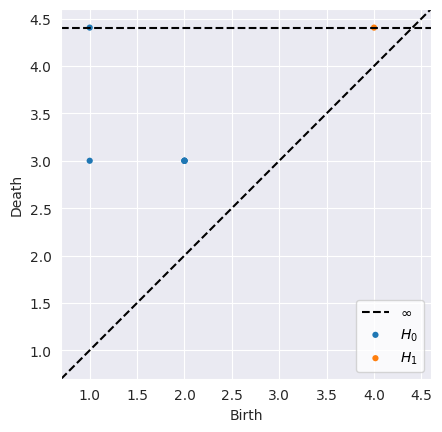

In [10]:
gp.persim_diagram(simplex_intervals=simplex_intervals)

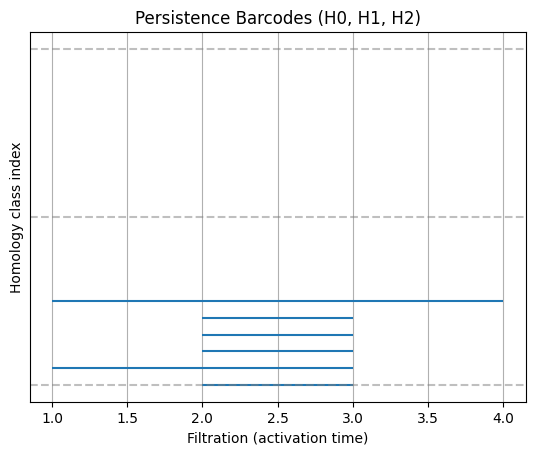

In [11]:
gp.plot_persistence_barcodes(simplex_intervals, activation_times, max_dim=2)

In [161]:
simplex_intervals[0][:][-1]

(4, [(2.0, 3.0), (1.0, 3.0), (2.0, 3.0), (2.0, 3.0), (2.0, 3.0), (1.0, inf)])

In [99]:
import persim

In [117]:
birth_death_simplex_intervals = dict()
for dim in range(2):
    birth_death_simplex_intervals[dim] = simplex_intervals[dim][-1][1]


H0_diag = npbirth_death_simplex_intervals[0]
H1_diag = np.array([(4, np.inf)])
# H2_diag = np.array(birth_death_simplex_intervals[2])

In [118]:
# birth_death_simplex_intervals[0]
# death_cap = 2 * np.max(np.isfinite(H0_diag[:, 1]) * H0_diag[:, 1])  # or just some large number like 10
H0_diag[~np.isfinite(H0_diag[:, 1]), 1] = 10
H1_diag[~np.isfinite(H1_diag[:, 1]), 1] = 10
#
#
# H0_diag = np.array(H0_diag, dtype=float)
# H1_diag = np.array(H1_diag, dtype=float)

TypeError: list indices must be integers or slices, not tuple

In [120]:
simplex_intervals[0][-1][1]

[(2.0, 3.0), (1.0, 3.0), (2.0, 3.0), (2.0, 3.0), (2.0, 3.0), (1.0, inf)]

In [107]:
# H0_vec = persim.PersistenceLandscaper(hom_deg=0, num_steps = 5, flatten = True).fit_transform([H0_diag])[0]
# H2_vec = persim.PersistenceLandscaper(hom_deg=2, num_steps = 100, flatten = True).fit_transform([H2_diag])[0]

In [124]:
H0_diag = np.array([(2.0, 3.0), (1.0, 3.0), (2.0, 3.0), (2.0, 3.0), (2.0, 3.0), (1.0, 10)])

pl = persim.PersistenceLandscaper(hom_deg = 0, start = 0, stop = 3,  num_steps = 10, flatten = True)
pl.fit([H0_diag])
H0_vec = pl.transform([H0_diag])[0]

In [129]:
H1_diag = [np.array([[4, 10]])]
pl = persim.PersistenceLandscaper(hom_deg = 1, num_steps = 10, flatten = True)
pl.fit(H1_diag)
H1_vec = pl.transform([H1_diag])

IndexError: list index out of range

In [157]:
max(simplex_intervals.keys())

2

In [131]:

def prepare_persim_diagrams(diag_dict, inf_replacement=10.0):
    result = []
    for hom_deg in sorted(diag_dict.keys()):
        all_pairs = []
        for _, pairs in diag_dict[hom_deg]:
            for birth, death in pairs:
                birth = float(birth)
                death = float('inf') if death == float('inf') else float(death)
                if np.isinf(death):
                    death = inf_replacement
                all_pairs.append((birth, death))
        result.append(np.array(all_pairs).reshape(-1, 2))
    return result


diagrams = prepare_persim_diagrams(simplex_intervals)

In [132]:
diagrams

[array([[ 0., 10.],
        [ 0., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 1., 10.],
        [ 2., 10.],
        [ 2., 10.],
        [ 2., 10.],
        [ 2., 10.],
        [ 2., 10.],
        [ 2., 10.],
        [ 2.,  3.],
        [ 1.,  3.],
        [ 2.,  3.],
        [ 2.,  3.],
        [ 2.,  3.],
        [ 1., 10.],
        [ 2.,  3.],
        [ 1.,  3.],
        [ 2.,  3.],
        [ 2.,  3.],
        [ 2.,  3.],
        [ 1., 10.]]),
 array([[ 4., 10.]]),
 array([], shape=(0, 2), dtype=float64)]

In [152]:
pl = persim.PersistenceLandscaper(hom_deg = 0, num_steps = 10, flatten = True)
pl.fit(diagrams)
vec0 = pl.transform(diagrams)
print(vec0)

[0.         1.11111111 2.22222222 3.33333333 4.44444444 4.44444444
 3.33333333 2.22222222 1.11111111 0.         0.         1.11111111
 2.22222222 3.33333333 4.44444444 4.44444444 3.33333333 2.22222222
 1.11111111 0.         0.         0.         1.11111111 2.22222222
 3.33333333 4.44444444 3.33333333 2.22222222 1.11111111 0.
 0.         0.         1.11111111 2.22222222 3.33333333 4.44444444
 3.33333333 2.22222222 1.11111111 0.         0.         0.
 1.11111111 2.22222222 3.33333333 4.44444444 3.33333333 2.22222222
 1.11111111 0.         0.         0.         1.11111111 2.22222222
 3.33333333 4.44444444 3.33333333 2.22222222 1.11111111 0.
 0.         0.         1.11111111 2.22222222 3.33333333 4.44444444
 3.33333333 2.22222222 1.11111111 0.         0.         0.
 1.11111111 2.22222222 3.33333333 4.44444444 3.33333333 2.22222222
 1.11111111 0.         0.         0.         1.11111111 2.22222222
 3.33333333 4.44444444 3.33333333 2.22222222 1.11111111 0.
 0.         0.         1.11111111 2

In [ ]:
pl1 = persim.PersistenceLandscaper(hom_deg = 1, num_steps = 10, flatten = False)
pl1.fit(diagrams)
vec1 = pl1.transform(diagrams)
print(vec1)

### Gughi Direct Persistence to Landscapes

In [334]:
import numpy as np
import pandas as pd
import importlib
import test_WTM as wtm
import gudhi_persistence as gp
import utilsA1 as utils
import os
from gudhi.persistence_graphical_tools import  plot_persistence_diagram, plot_persistence_barcode
from sklearn.decomposition import PCA
import gudhi
import networkx as nx
import persim

In [331]:

importlib.reload(wtm)
importlib.reload(utils)
importlib.reload(gp)

PATH = os.getcwd()
output_file = "test_updates"
params_temp_list = {'num_nodes': 60, 'num_neighbor_nodes': 1,
                    'total_random_edges': 3, 'distance_threshold': 2, 'weighted': False,
                    'ngeo_placement': 'ngeo_per_node', 'n_seeds': 1, 'node_active_threshold': 0.01,
                    'upper_weight_limit': 5, 'skew_power': 3, 'seed_cluster_distance': 10,
                    'ngeom_edges_in_persistence': False, 'max_persistence_dim': 2,
                    'seeding_method': 'all_combinations', 'calculate_representation': True}

params_temp_list['threshold_sum']= sum(range(params_temp_list['num_nodes'])) - 200

df, activation_results = wtm.main_sims(params_list=[params_temp_list],
                   output_file=output_file, save_files=False)
#
# G, seed_nodes = wtm.simulate_contagion_map(params=params_temp_list)
# graph, snapshots, activation_times, results = wtm.simulate_contagion_realization(graph = G, init_seeds = seed_nodes, params = params_temp_list,
# max_steps = 100, sim_id = 1, realization_id = 1, calculate_representaion=True)
#
# utils.visualize_step_animation_new(G=graph, snapshots=snapshots,
#                          output_file= os.path.join(PATH, 'Outputs', f"{output_file}.html"))

Calculating representation


In [370]:
df

,simulation_id,realization_id,num_nodes,time,state,state_abnormal_sum,num_active_nodes,active_nodes,node_active_threshold,H0,...,L_1,L_2,I_0,I_1,I_2,E_0,E_1,E_2,start,stop
0,0,0,60,0,0,1769,1,"[0.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]",0.01,1,...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]]",0,0,0,0,1.0
1,0,0,60,1,0,1769,6,"[0.0, 1.0, nan, nan, nan, nan, nan, nan, 1.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 1.0, 1.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 1.0]",0.01,3,...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 

In [363]:

# Define columns to apply PCA on
landscape_cols = ['L_0', 'L_1', 'L_2']
image_cols = ['I_0', 'I_1', 'I_2']

# How many components you want
n_components = 3  # or choose later by explained variance

# Create a new DataFrame to store PCA features
df_pca = df[['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2']].copy()
# --- FUNCTION TO RUN PCA AND ADD TO df_pca ---
def apply_pca_and_add(df, feature_col, prefix):
    """
    Applies PCA to a column of vector data in a DataFrame and adds PCA components to df_pca.
    Skips if there are no valid arrays to stack.
    """
    valid_mask = df[feature_col].apply(lambda x: isinstance(x, np.ndarray) and not np.isnan(x).any())
    valid_df = df[valid_mask]

    # Skip if no valid arrays to process
    if valid_df.empty:
        print(f"Skipping {feature_col} — no valid data.")
        return

    # Stack the features into a 2D array
    X = np.vstack(valid_df[feature_col].values)

    # Check shape
    if X.shape[0] == 0:
        print(f"Skipping {feature_col} — empty after stacking.")
        return

    # Fit PCA
    pca = PCA(n_components=min(n_components, X.shape[0]))
    X_pca = pca.fit_transform(X)
    print(f"Explained variance ratio: {pca.explained_variance_ratio_.cumsum()}")


    # Create PCA column names
    pca_cols = [f"{prefix}_PC{i+1}" for i in range(X_pca.shape[1])]

    # Create temp DataFrame with PCA results
    temp = valid_df[['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2']].copy()
    temp[pca_cols] = X_pca

    # Merge back
    global df_pca
    df_pca = df_pca.merge(temp, on=['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2'], how='left')



In [364]:
# Apply PCA for each landscape dimension
for col in landscape_cols:
    apply_pca_and_add(df, col, prefix=col)

# Apply PCA for each image dimension
for col in image_cols:
    apply_pca_and_add(df, col, prefix=col)

Explained variance ratio: [0.63169891 0.84546572 0.91890959]
Skipping L_1 — no valid data.
Skipping L_2 — no valid data.
Explained variance ratio: [0.51261425 0.79278335 0.94517122]
Skipping I_1 — no valid data.
Skipping I_2 — no valid data.


In [365]:
df_pca

,simulation_id,realization_id,time,state,E_0,E_1,E_2,L_0_PC1,L_0_PC2,L_0_PC3,I_0_PC1,I_0_PC2,I_0_PC3
0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,0,0,2,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,0,0,3,0,6,0,0,-1.902952,0.406160,-0.315469,-29.466601,-91.897087,-29.287087
4,0,0,4,1,6,0,0,-0.857809,0.198981,-0.728007,-62.313570,-46.454838,-54.574651
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0,59,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
296,0,59,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
297,0,59,2,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
298,0,59,3,0,7,0,0,-1.902952,0.406160,-0.315469,-29.466601,-91.897087,-29.287087


In [366]:
landscape_cols = [col for col in df_pca.columns if col.startswith("L_") or col.startswith("I_") or col.startswith("E_")]

df_pca[landscape_cols] = df_pca[landscape_cols].applymap(
    lambda x: np.zeros_like(x) if isinstance(x, float) and np.isnan(x) else x
)
df_pca = df_pca.sort_values(["simulation_id", "realization_id", "time"])

df_pca["start"] = df_pca["time"]
df_pca["stop"] = df_pca.groupby(["simulation_id", "realization_id"])["time"].shift(-1)
df_pca["stop"] = df_pca["stop"].fillna(df_pca["start"] + 1)

df_pca

C:\Users\sranasin\AppData\Local\Temp\ipykernel_292\491764533.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_pca[landscape_cols] = df_pca[landscape_cols].applymap(


,simulation_id,realization_id,time,state,E_0,E_1,E_2,L_0_PC1,L_0_PC2,L_0_PC3,I_0_PC1,I_0_PC2,I_0_PC3,start,stop
0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,1.0
1,0,0,1,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,2.0
2,0,0,2,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2,3.0
3,0,0,3,0,6,0,0,-1.902952,0.406160,-0.315469,-29.466601,-91.897087,-29.287087,3,4.0
4,0,0,4,1,6,0,0,-0.857809,0.198981,-0.728007,-62.313570,-46.454838,-54.574651,4,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0,59,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,1.0
296,0,59,1,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,2.0
297,0,59,2,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2,3.0
298,0,59,3,0,7,0,0,-1.902952,0.406160,-0.315469,-29.466601,-91.897087,-29.287087,3,4.0


In [367]:
# Identify landscape and image columns
landscape_cols = sorted([col for col in df_pca.columns if col.startswith("L_")])
image_cols = sorted([col for col in df_pca.columns if col.startswith("I_")])
essentials_cols = sorted([col for col in df_pca.columns if col.startswith("E_")])
# Define the desired column order
ordered_cols = ["simulation_id", "realization_id", "start", "stop", "state"] + landscape_cols + image_cols + essentials_cols

# Reorder the DataFrame
df_pca = df_pca[ordered_cols]
df_pca

,simulation_id,realization_id,start,stop,state,L_0_PC1,L_0_PC2,L_0_PC3,I_0_PC1,I_0_PC2,I_0_PC3,E_0,E_1,E_2
0,0,0,0,1.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
1,0,0,1,2.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
2,0,0,2,3.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
3,0,0,3,4.0,0,-1.902952,0.406160,-0.315469,-29.466601,-91.897087,-29.287087,6,0,0
4,0,0,4,5.0,1,-0.857809,0.198981,-0.728007,-62.313570,-46.454838,-54.574651,6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0,59,0,1.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
296,0,59,1,2.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
297,0,59,2,3.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
298,0,59,3,4.0,0,-1.902952,0.406160,-0.315469,-29.466601,-91.897087,-29.287087,7,0,0


In [147]:
importlib.reload(gp)
betti_numbers, persistence, persistence_intervals_for_diagram = gp.compute_persistence(graph=graph, activation_times=activation_times, max_dim=2)

OUT_FILE = 'gp_tests'
PATH = os.getcwd()
# utils.visualize_step_animation_new(G=G, snapshots = snapshots, output_file=os.path.join(PATH, 'Outputs', f"{OUT_FILE}.html"))
print(f"Graphs @: file:///C:/Users/sranasin/Desktop/NetworkModels/Project1/A1/Outputs/{OUT_FILE}.html")
print(" ")
print(f"Activation Times: {activation_times}")
print(" ")

for t in range(int(np.nanmax(activation_times)) + 1):
    print(f"Betti Numbers at {t}: {betti_numbers[t]}")


Graphs @: file:///C:/Users/sranasin/Desktop/NetworkModels/Project1/A1/Outputs/gp_tests.html
 
Activation Times: [3. 2. 2. 1. 2. 2. 2. 2. 1. 2. 3. 3. 3. 2. 3. 3. 3. 2. 2. 2. 1. 1. 2. 2.
 1. 0. 1. 2. 2. 1. 2. 2. 1. 0. 1. 2. 3. 3. 2. 3. 3. 2. 3. 3. 3. 2. 3. 2.
 1. 2. 2. 3. 2. 2. 3. 4. 3. 3. 3. 3.]
 
Betti Numbers at 0: {0: 2, 1: 0, 2: 0}
Betti Numbers at 1: {0: 7, 1: 0, 2: 0}
Betti Numbers at 2: {0: 8, 1: 0, 2: 0}
Betti Numbers at 3: {0: 1, 1: 0, 2: 0}
Betti Numbers at 4: {0: 1, 1: 1, 2: 0}


In [230]:
from gudhi.representations import DiagramSelector, DiagramScaler
from sklearn.preprocessing import MinMaxScaler

proc_essential = DiagramSelector(use = False, point_type='essential')
proc_finite = DiagramSelector(use=True, point_type='finite')
proc_scaler = DiagramScaler(use = True, scalers=[([0, 1], MinMaxScaler())])
persistence_in_dim = np.vstack(persistence[:, 0])
persistence_in_dim = np.asarray(persistence_in_dim, dtype = np.float64)

print(len(proc_essential(persistence_in_dim)))
print(proc_scaler(proc_finite(persistence_in_dim)))


31
[[0.  0.5]
 [0.  0.5]
 [0.  0.5]
 [0.  0.5]
 [0.5 1. ]
 [0.5 1. ]
 [0.5 1. ]
 [0.  0.5]
 [0.  0.5]
 [0.5 1. ]
 [0.5 1. ]
 [0.5 1. ]]


In [232]:
from gudhi.representations import DiagramSelector, DiagramScaler, Landscape, PersistenceImage, Clamping
from sklearn.preprocessing import MinMaxScaler
from collections import defaultdict

In [265]:
resolution = 50; num_landscapes = 3; bandwidth = 0.1
max_dim = persistence.shape[1]
timesteps = persistence.shape[0]
# preprocessing
proc_finite = DiagramSelector(use=True, point_type='finite')
proc_essential = DiagramSelector(use=False, point_type='essential')
proc_scaler = DiagramScaler(use=True, scalers=[([0, 1], MinMaxScaler())])
proc_clamp = DiagramScaler(use=True, scalers=[([1], Clamping(maximum=.9))])
call_plandscape = Landscape(resolution=resolution, num_landscapes=num_landscapes)
call_pimage = PersistenceImage(bandwidth=bandwidth, weight=lambda x: x[1], im_range=[0, 1, 0, 1], resolution=[resolution, resolution])
params = {'num_landscapes': num_landscapes, 'bandwidth': bandwidth, 'resolution': resolution,
          'pre-processing': ['finite', 'mix_max_scaler', 'clamp']}
L = defaultdict()
I = defaultdict()
essential_features = defaultdict()
for timestep in range(timesteps):
    L_d = []
    I_d = []
    E_d = [0] * max_dim
    for dim in range(max_dim):
        print(f"Dimension: {dim}, timestep: {timestep}")
        L_d.append(np.zeros((resolution * num_landscapes, )))
        I_d.append(np.zeros((resolution * resolution, )))
        if len(persistence[timestep, dim]) == 0:
            print("skipping no features")
            continue
        persistence_in_dim = np.vstack(persistence[timestep, dim])
        print(f"persistence_in_dim: {persistence_in_dim}")
        print(f" Essential features: {len(proc_essential(persistence_in_dim))} in dim: {dim}")
        print("~~~")
        # skip to next dim if current dim has no finite points (which is the case for homology dim = 2 (sometimes 1)
        if len(proc_finite(persistence_in_dim)) == 0:
            print("skipping finite")
            continue
        diagram = proc_clamp(proc_scaler(proc_finite(persistence_in_dim)))
        diagram = np.asarray(diagram, dtype = np.float64)

        E_d[dim] = len(proc_essential(persistence_in_dim))
        v_landscape = call_plandscape(diagram)
        v_image = call_pimage(diagram)
        L_d.append(v_landscape)
        I_d.append(v_image)
    L[timestep] = L_d
    I[timestep] = I_d
    essential_features[timestep] = E_d

Dimension: 0, timestep: 0
persistence_in_dim: [[0.0 inf]
 [0.0 inf]]
 Essential features: 2 in dim: 0
~~~
skipping finite
Dimension: 1, timestep: 0
skipping no features
Dimension: 2, timestep: 0
skipping no features
Dimension: 0, timestep: 1
persistence_in_dim: [[1.0 inf]
 [1.0 inf]
 [1.0 inf]
 [1.0 inf]
 [1.0 inf]
 [1.0 inf]
 [1.0 inf]]
 Essential features: 7 in dim: 0
~~~
skipping finite
Dimension: 1, timestep: 1
skipping no features
Dimension: 2, timestep: 1
skipping no features
Dimension: 0, timestep: 2
persistence_in_dim: [[1.0 2.0]
 [1.0 2.0]
 [2.0 inf]
 [2.0 inf]
 [2.0 inf]
 [2.0 inf]
 [2.0 inf]
 [2.0 inf]
 [2.0 inf]
 [1.0 inf]]
 Essential features: 10 in dim: 0
~~~
Dimension: 1, timestep: 2
skipping no features
Dimension: 2, timestep: 2
skipping no features
Dimension: 0, timestep: 3
persistence_in_dim: [[1.0 2.0]
 [1.0 2.0]
 [2.0 3.0]
 [2.0 3.0]
 [2.0 3.0]
 [1.0 inf]]
 Essential features: 6 in dim: 0
~~~
Dimension: 1, timestep: 3
skipping no features
Dimension: 2, timestep: 3
s

In [270]:
L[0]

[array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.

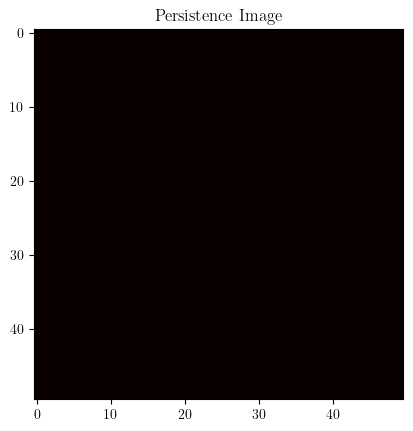

In [256]:
plt.imshow(np.flip(np.reshape(I[0][1], [50,50]), 0), cmap = 'hot')
plt.title("Persistence Image")
plt.show()

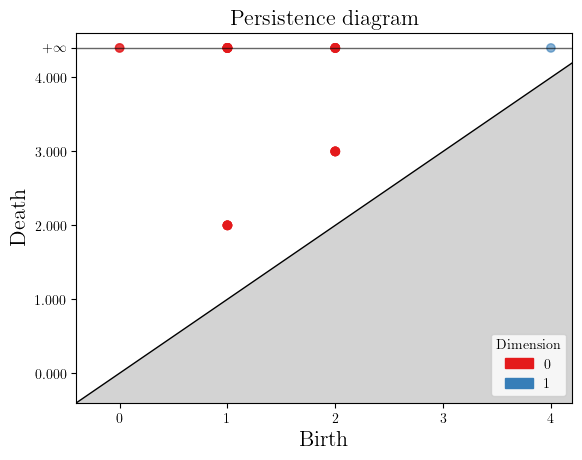

In [124]:
importlib.reload(gp)

gp.persistence_diagram(persistence_intervals_for_diagram)

In [212]:
persistence[:, 2]

array([array([], shape=(0, 2), dtype=object),
       array([], shape=(0, 2), dtype=object),
       array([], shape=(0, 2), dtype=object),
       array([], shape=(0, 2), dtype=object),
       array([], shape=(0, 2), dtype=object)], dtype=object)

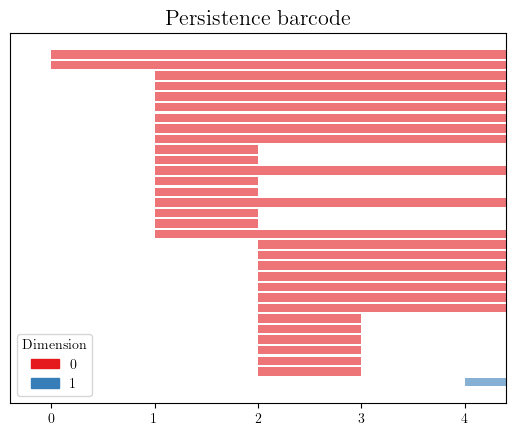

In [125]:
importlib.reload(gp)

gp.persistence_barcodes(persistence_intervals_for_diagram)

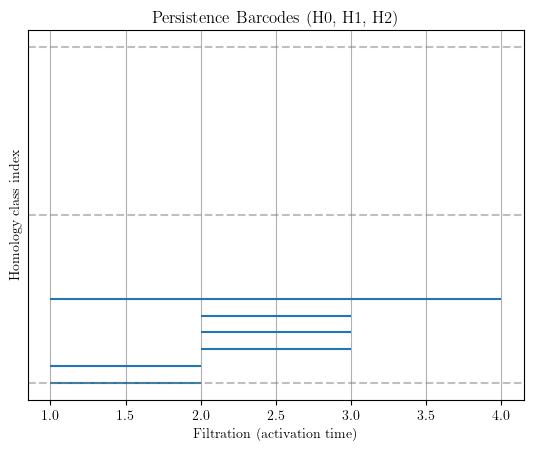

In [122]:
gp.plot_persistence_barcodes(simplex_intervals=simplex_intervals, activation_times=activation_times)

In [194]:
print(np.vstack(persistence[:, 0]))

[[0.0 inf]
 [0.0 inf]
 [1.0 inf]
 [1.0 inf]
 [1.0 inf]
 [1.0 inf]
 [1.0 inf]
 [1.0 inf]
 [1.0 inf]
 [1.0 2.0]
 [1.0 2.0]
 [2.0 inf]
 [2.0 inf]
 [2.0 inf]
 [2.0 inf]
 [2.0 inf]
 [2.0 inf]
 [2.0 inf]
 [1.0 inf]
 [1.0 2.0]
 [1.0 2.0]
 [2.0 3.0]
 [2.0 3.0]
 [2.0 3.0]
 [1.0 inf]
 [1.0 2.0]
 [1.0 2.0]
 [2.0 3.0]
 [2.0 3.0]
 [2.0 3.0]
 [1.0 inf]]


In [208]:
from gudhi.representations import DiagramSelector, DiagramScaler, Landscape, Clamping, PersistenceImage
from sklearn.preprocessing import MinMaxScaler
resolution = 100
num_landscapes = 3
max_persistence_dim = params_temp_list.get('max_persistence_dim')
proc_finite = DiagramSelector(use = True, point_type='finite')
proc_scaler = DiagramScaler(use=True, scalers=[([0,1], MinMaxScaler())])
proc_clamp = DiagramScaler(use=True, scalers=[([1], Clamping(maximum=.9))])
call_landscape = Landscape(resolution=resolution,  num_landscapes=num_landscapes)
call_pi = PersistenceImage(bandwidth=.1, weight=lambda x: x[1], im_range=[0,1,0,1], resolution=[100,100])
L = []
I = dict()

# PI = PersistenceImage(bandwidth=.1, weight=lambda x: x[1], im_range=[0,1,0,1], resolution=[100,100])
# print(D1)
# plt.imshow(np.flip(np.reshape(PI(D1), [100,100]), 0))
# plt.title("Persistence Image")
# plt.show()
for dim in range(max_persistence_dim + 1):
    print(f"Dim {dim}: {dim}")
    persistence_temp = persistence[:, dim]
    dim_persistence = np.vstack(persistence_temp)
    if len(proc_finite(dim_persistence)) == 0:
        continue
    diag = proc_clamp(proc_scaler(proc_finite(dim_persistence)))
    print(f"Dim {dim} with length: {diag.shape}, with type: {diag.dtype}")
    diag = np.asarray(diag, dtype=np.float64)
    if len(diag) == 0:
        continue
    v_landscape = call_landscape(diag)
    v_pi = call_pi(diag)
    L.append(v_landscape)
    I[dim] = v_pi

L_array = np.stack(L)

Dim 0: 0
Dim 0 with length: (12, 2), with type: object
Dim 1: 1
Dim 2: 2


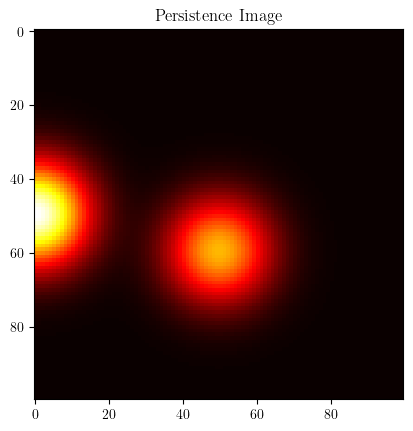

In [209]:
plt.imshow(np.flip(np.reshape(I[0], [100,100]), 0), cmap = 'hot')
plt.title("Persistence Image")
plt.show()

In [180]:
print(L_array[0][1:10])
print(L_array[0][100:110])

[0.02520381 0.03780571 0.05040761 0.06300952 0.07561142 0.08821332
 0.10081522 0.11341713 0.12601903]
[0.0126019  0.02520381 0.03780571 0.05040761 0.06300952 0.07561142
 0.08821332 0.10081522 0.11341713 0.12601903]


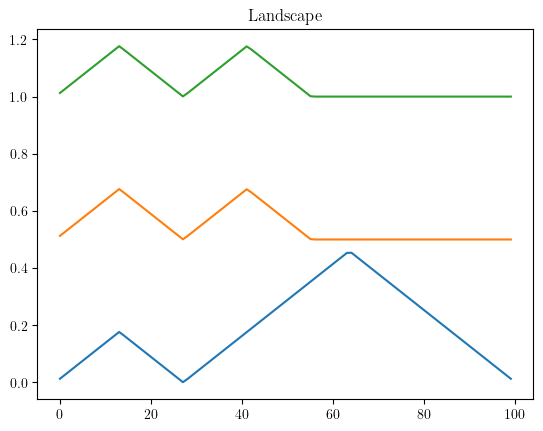

In [181]:
plt.plot(L_array[0][:resolution])
plt.plot(L_array[0][resolution:resolution*2] + 0.5)
plt.plot(L_array[0][resolution*2: resolution*3] + 1)
plt.title("Landscape")
plt.show()

In [153]:

proc_finite = DiagramSelector(use = True, point_type='finite')
test_array = np.array([[0.,4.],[1.,2.],[3.,8.],[6.,8.], [0., np.inf], [5., np.inf]])
persistence_temp = np.vstack(persistence[:, 0])

diag = proc_finite(persistence_temp)
diag_test = proc_finite(test_array)



print(f"shape of test_array: {diag_test.shape}")
print(f"shape of persistence: {diag.shape}")
print(diag)

shape of test_array: (4, 2)
shape of persistence: (12, 2)
[[1.0 2.0]
 [1.0 2.0]
 [1.0 2.0]
 [1.0 2.0]
 [2.0 3.0]
 [2.0 3.0]
 [2.0 3.0]
 [1.0 2.0]
 [1.0 2.0]
 [2.0 3.0]
 [2.0 3.0]
 [2.0 3.0]]


Text(0.5, 0.98, 'Persistence Diagram')

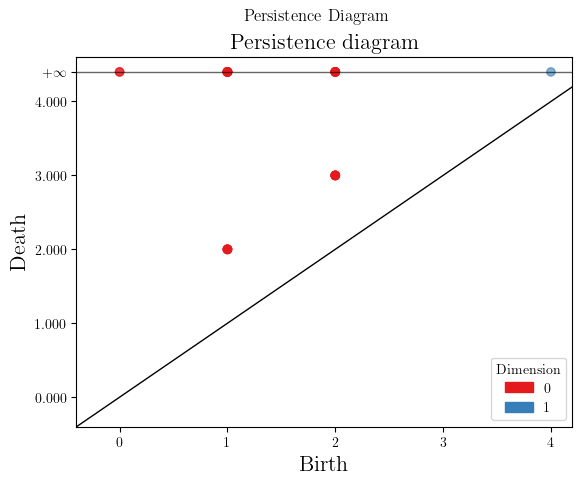

In [107]:


ax_diagram = plot_persistence_diagram(persistence_intervals_for_diagram, legend = True)
fig_diagram = ax_diagram.get_figure()
fig_diagram.suptitle('Persistence Diagram')

In [102]:
simplex_intervals

defaultdict(list,
            {0: [(0, [(0.0, inf), (0.0, inf)]),
              (1,
               [(1.0, inf),
                (1.0, inf),
                (1.0, inf),
                (1.0, inf),
                (1.0, inf),
                (1.0, inf),
                (1.0, inf)]),
              (2,
               [(1.0, 2.0),
                (1.0, 2.0),
                (2.0, inf),
                (2.0, inf),
                (2.0, inf),
                (2.0, inf),
                (2.0, inf),
                (2.0, inf),
                (2.0, inf),
                (1.0, inf)]),
              (3,
               [(1.0, 2.0),
                (1.0, 2.0),
                (2.0, 3.0),
                (2.0, 3.0),
                (2.0, 3.0),
                (1.0, inf)]),
              (4,
               [(1.0, 2.0),
                (1.0, 2.0),
                (2.0, 3.0),
                (2.0, 3.0),
                (2.0, 3.0),
                (1.0, inf)])],
             1: [(0, []), (1, []), (2, []

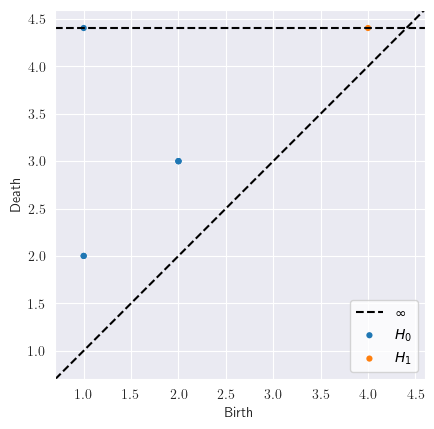

In [101]:
gp.persim_diagram(simplex_intervals=simplex_intervals)

In [76]:
from gudhi.representations import Clamping, Landscape, BettiCurve, DiagramSelector, DiagramScaler
from sklearn.preprocessing import MinMaxScaler
test_array = np.array([[0.,4.],[1.,2.],[3.,8.],[6.,8.], [0., np.inf], [5., np.inf]])

proc_clamp = DiagramScaler(use=True, scalers=[([1], Clamping(maximum=0.9))])
proc_scaler = DiagramScaler(use=True, scalers=[([0, 1], MinMaxScaler())])
proc_finite = DiagramSelector(use=True, point_type='finite')


res = proc_clamp(proc_scaler(proc_finite(test_array)))
print(res)


print(f"x values: {res[:, 1]}")

[[0.    0.5  ]
 [0.125 0.25 ]
 [0.375 0.9  ]
 [0.75  0.9  ]]
x values: [0.5  0.25 0.9  0.9 ]


In [ ]:
from gudhi.representations import Clamping, Landscape, BettiCurve, DiagramSelector, DiagramScaler
from sklearn.preprocessing import MinMaxScaler



In [162]:
L[:100]

[array([0.0280042289578831, 0.0560084579157662, 0.0840126868736493,
        0.1120169158315324, 0.1400211447894155, 0.1680253737472986,
        0.1960296027051817, 0.22403383166306445, 0.2520380606209476,
        0.28004228957883065, 0.3080465185367138, 0.33605074749459685,
        0.36405497645248, 0.39205920541036304, 0.42006343436824617,
        0.44806766332612924, 0.4760718922840123, 0.5040761212418952,
        0.5320803501997782, 0.5600845791576613, 0.5880888081155444,
        0.6160930370734276, 0.6440972660313106, 0.6721014949891937,
        0.7001057239470768, 0.6861036094681352, 0.6580993805102522,
        0.6300951515523691, 0.6020909225944859, 0.5740866936366028,
        0.5460824646787198, 0.5180782357208367, 0.4900740067629536,
        0.46206977780507047, 0.4340655488471874, 0.4060613198893046,
        0.3780570909314215, 0.3500528619735384, 0.3220486330156553,
        0.2940444040577722, 0.2660401750998891, 0.23803594614200632,
        0.21003171718412322, 0.18202748822

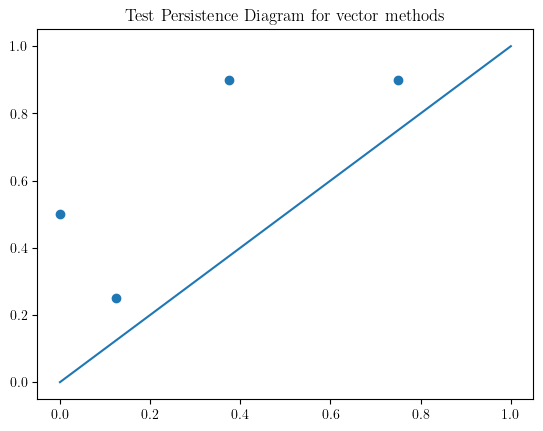

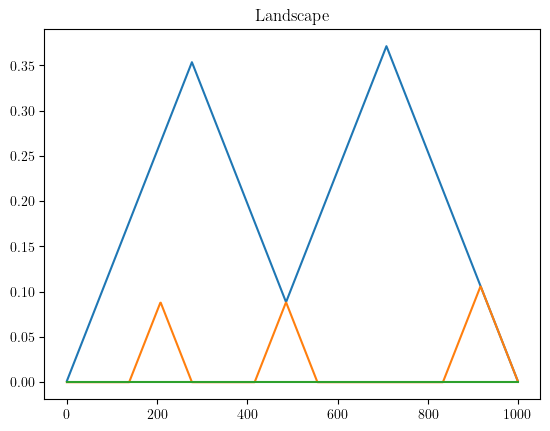

In [188]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.kernel_approximation import RBFSampler
from sklearn.preprocessing import MinMaxScaler

from gudhi.representations import (DiagramSelector, Clamping, Landscape, Silhouette, BettiCurve, ComplexPolynomial,\
  TopologicalVector, DiagramScaler, BirthPersistenceTransform,\
  PersistenceImage, PersistenceWeightedGaussianKernel, Entropy, \
  PersistenceScaleSpaceKernel, SlicedWassersteinDistance,\
  SlicedWassersteinKernel, PersistenceFisherKernel, WassersteinDistance)

D1 = np.array([[0.,4.],[1.,2.],[3.,8.],[6.,8.], [0., np.inf], [5., np.inf]])

proc1 = DiagramSelector(use=True, point_type="finite")
proc2 = DiagramScaler(use=True, scalers=[([0,1], MinMaxScaler())])
proc3 = DiagramScaler(use=True, scalers=[([1], Clamping(maximum=.9))])
D1 = proc3(proc2(proc1(D1)))

plt.scatter(D1[:,0], D1[:,1])
plt.plot([0.,1.],[0.,1.])
plt.title("Test Persistence Diagram for vector methods")
plt.show()

LS = Landscape(resolution=1000)
L = LS(D1)
plt.plot(L[:1000])
plt.plot(L[1000:2000])
plt.plot(L[2000:3000])
plt.title("Landscape")
plt.show()

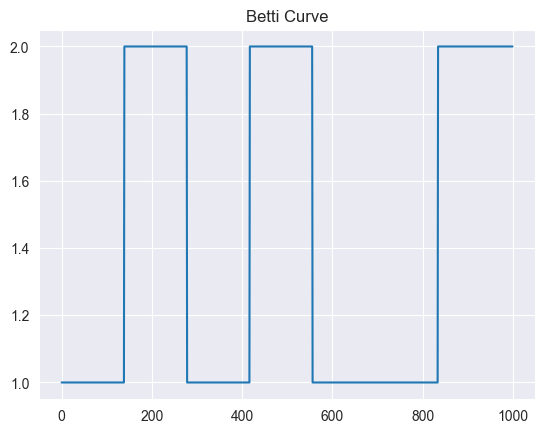

In [61]:
BC = BettiCurve(resolution=1000)
plt.plot(BC(D1))
plt.title("Betti Curve")
plt.show()

[[0.    0.5  ]
 [0.125 0.25 ]
 [0.375 0.9  ]
 [0.75  0.9  ]]


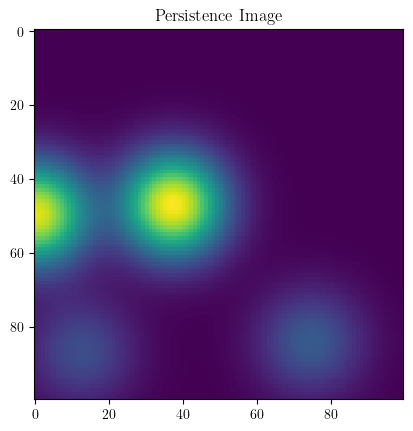

In [190]:
PI = PersistenceImage(bandwidth=.1, weight=lambda x: x[1], im_range=[0,1,0,1], resolution=[100,100])
print(D1)
plt.imshow(np.flip(np.reshape(PI(D1), [100,100]), 0))
plt.title("Persistence Image")
plt.show()

In [57]:
D = np.array([[0.,4.],[1.,2.],[3.,8.],[6.,8.]])
# landscape = gudhi.representations.Landscape
diags = [D]
diags


[array([[0., 4.],
        [1., 2.],
        [3., 8.],
        [6., 8.]])]

In [47]:
importlib.reload(gp)


landscape_matrix_dict = gp.persistence_landscapes_old(simplex_intervals=simplex_intervals,
                                                      num_steps = 10, inf_replacement = 10.0,
                                                      flatten = False
                                                      )

t: 0, hom_deg: 0, and diagram: [array([[ 0., 10.],
       [ 0., 10.]])]
t: 0, hom_deg: 0, and diagram: [array([[ 0., 10.],
       [ 0., 10.]])]
t: 0, hom_deg: 0, and diagram: [array([[ 0., 10.],
       [ 0., 10.]])]
t: 1, hom_deg: 0, and diagram: [array([[ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.]])]
t: 1, hom_deg: 0, and diagram: [array([[ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.]])]
t: 1, hom_deg: 0, and diagram: [array([[ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.],
       [ 1., 10.]])]
t: 2, hom_deg: 0, and diagram: [array([[ 1.,  2.],
       [ 1.,  2.],
       [ 2., 10.],
       [ 2., 10.],
       [ 2., 10.],
       [ 2., 10.],
       [ 2., 10.],
       [ 2., 10.],
       [ 2., 10.],
       [ 1., 10.]])]
t: 2, hom_deg: 0, and diagram: [array([[ 1.,  2.],
       [

In [407]:
import gudhi as gd
PATH = os.getcwd()
output_file = "gudhi_test"
params_temp_list = {'num_nodes': 40, 'num_neighbor_nodes': 1,
                    'total_random_edges': 12, 'distance_threshold': 2, 'weighted': False,
                    'ngeo_placement': 'random.choice', 'n_seeds': 1, 'node_active_threshold': 0.01,
                    'upper_weight_limit': 5, 'skew_power': 3, 'seed_cluster_distance': 10,
                    'ngeom_edges_in_persistence': False, 'max_persistence_dim': 2,
                    'seeding_method': 'all_combinations', 'calculate_representation': True,
                    'bandwidth': 0.1, 'num_landscapes': 3, 'resolution': 50}

params_temp_list['threshold_sum']= sum(range(params_temp_list['num_nodes'])) - 200

def clean_inputs(graph, activation_times, ngeom_edges_in_persistence):

    if ngeom_edges_in_persistence:
        G = graph
    else: ######### TEMPORARY, Change to use a distance threshold to see which are geom and ngeom
        G = nx.Graph()
        G.add_nodes_from(graph.nodes(data = True))
        G.add_edges_from([(u, v, d) for u, v, d in graph.edges(data=True) if d.get('type') == 'geometric'])

    G = nx.relabel_nodes(G, lambda x: int(x))
    activation = np.array([int(x)
                           if not np.isnan(x) else np.nan
                           for x in activation_times], dtype='object')
    return G, activation

In [408]:
importlib.reload(wtm)
importlib.reload(utils)
importlib.reload(gp)


params_temp_list['seeding_method'] = 'cluster_seeding'
G, seed_nodes = wtm.simulate_contagion_map(params=params_temp_list)
graph, snapshots, activation_times, results = wtm.simulate_contagion_realization(graph = G, init_seeds = seed_nodes, params = params_temp_list,
max_steps = 100, sim_id = 1, realization_id = 1)

utils.visualize_step_animation_new(G=graph, snapshots=snapshots,
                         output_file= os.path.join(PATH, 'Outputs', f"{output_file}.html"))
print(f"Graphs @: file:///C:/Users/sranasin/Desktop/NetworkModels/Project1/A1/Outputs/{output_file}.html")


graph, activation = clean_inputs(graph, activation_times, bool(False))


Graphs @: file:///C:/Users/sranasin/Desktop/NetworkModels/Project1/A1/Outputs/gudhi_test.html


In [409]:
# outside of loop
#
betti_over_time = {}
simplex_intervals = defaultdict(list)
persistence = np.empty((int(np.nanmax(activation)) + 1,
                                      max_dim + 1), dtype = object)
persistence_for_graphics = []  ## gudhi tools requires a special format for diagrams


for t in range(np.nanmax(activation) + 1):
    # print(f"---------- Filtration Time Step: {t} ------------")
    tree = gd.simplex_tree.SimplexTree(None)
    tree.make_filtration_non_decreasing()
    # tree.initialize_filtration()

    active_nodes = [node for node, time in enumerate(activation) if time <= t]

    # Create a subgraph at time = t,
    # Add all current nodes and edges
    subg = graph.subgraph(active_nodes).copy()

    for node in subg.nodes():
        tree.insert([node], filtration=t)
    for u, v, labels in subg.edges(data = True):
        if labels['weight'] < t:
            edge_filtration = max(activation[u], activation[v])
            tree.insert([u, v], filtration=edge_filtration)

    interavls = tree.persistence(persistence_dim_max=2)
    print(f"Time {t}, intervals: {interavls}")

Time 0, intervals: [(0, (0.0, inf))]
Time 1, intervals: [(0, (1.0, inf)), (0, (1.0, inf))]
Time 2, intervals: [(0, (1.0, inf)), (0, (2.0, inf)), (0, (2.0, inf)), (0, (2.0, inf)), (0, (2.0, inf))]
Time 3, intervals: [(0, (1.0, inf)), (0, (2.0, inf)), (0, (3.0, inf)), (0, (3.0, inf)), (0, (3.0, inf))]
Time 4, intervals: [(0, (1.0, inf)), (0, (2.0, inf)), (0, (3.0, inf))]
Time 5, intervals: [(0, (1.0, inf)), (0, (2.0, inf)), (0, (3.0, 5.0))]
Time 6, intervals: [(0, (1.0, inf)), (0, (2.0, 6.0)), (0, (3.0, 5.0))]
Time 7, intervals: [(1, (7.0, inf)), (0, (1.0, inf)), (0, (2.0, 6.0)), (0, (3.0, 5.0))]


In [405]:
### within loop
for t in range(np.nanmax(activation) + 1):
    # print(f"---------- Filtration Time Step: {t} ------------")
    tree1 = gd.simplex_tree.SimplexTree(None)
    tree1.make_filtration_non_decreasing()
    # tree.initialize_filtration()

    active_nodes = [node for node, time in enumerate(activation) if time <= t]

    # Create a subgraph at time = t,
    # Add all current nodes and edges
    subg = graph.subgraph(active_nodes).copy()

    for node in subg.nodes():
        tree1.insert([node], filtration=t)
    for u, v, labels in subg.edges(data = True):
        if labels['weight'] < t:
            edge_filtration = max(activation[u], activation[v])
            tree1.insert([u, v], filtration=edge_filtration)

tree1.compute_persistence()
intervals = tree1.persistence_pairs()
print(f"intervals: {intervals}")

intervals: [([4], [11, 10]), ([13], [])]


C:\Users\sranasin\AppData\Roaming\Python\Python312\site-packages\gudhi\persistence_graphical_tools.py:277: SyntaxWarning: invalid escape sequence '\l'
  """This function plots the persistence diagram from persistence values list, a np.array of shape (N x 2)


ValueError: not enough values to unpack (expected 2, got 0)

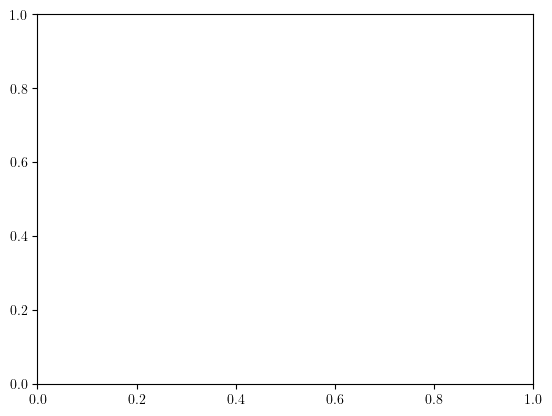

In [400]:
gp.persistence_barcodes(intervals)